In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load AirPassengers (monthly airline passengers 1949–1960)
# Or read directly from a common online source:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(
    url,
    index_col='Month',      # Use the 'Month' column as the index
    parse_dates=True        # Parse the index as dates
)

/workspaces/.venv/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


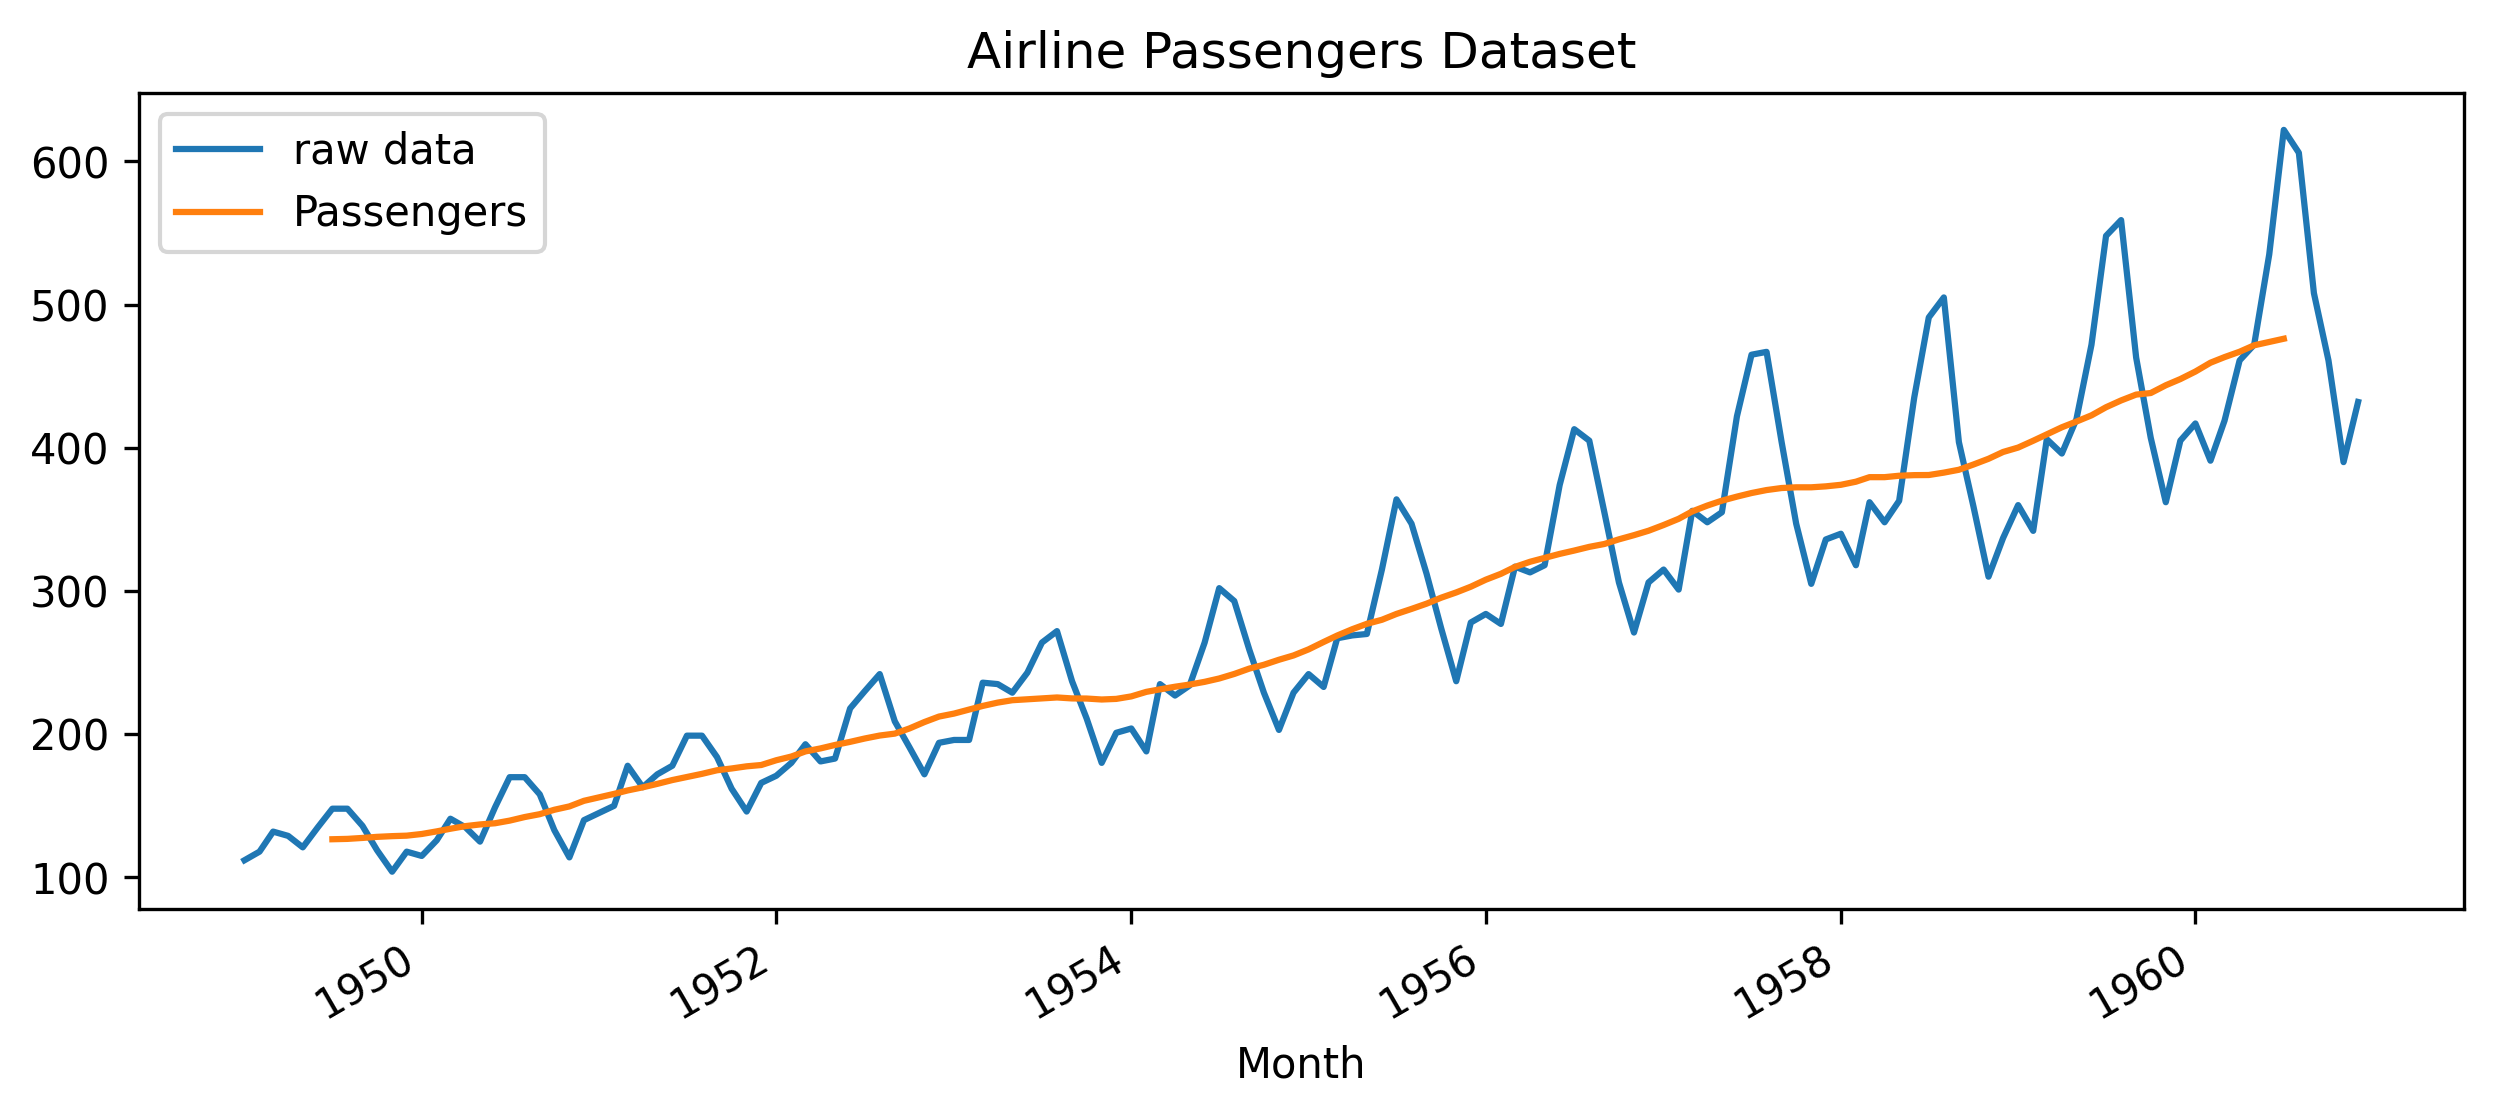

In [3]:
fig,ax=plt.subplots(1,1,figsize=[10,4],dpi=300)
ax.plot(data.index, data["Passengers"],label='raw data')
data.rolling(window=12,center=True).mean().plot(label='12 month rolling mean', ax=ax)
ax.set_title("Airline Passengers Dataset")
ax.legend()

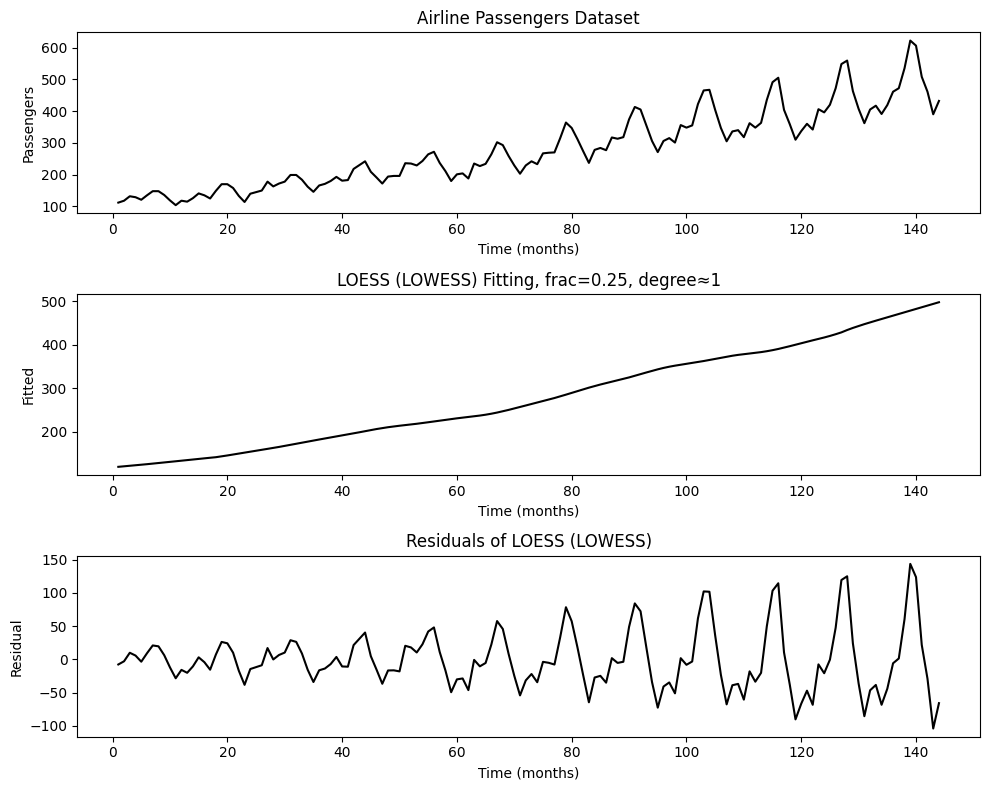

In [4]:

AP = data['Passengers'].to_numpy()      # numeric array (like unclass in R)
x = np.arange(1, len(AP) + 1)      # 1..144
y = AP.copy()

# 2) LOESS/LOWESS fit
from statsmodels.nonparametric.smoothers_lowess import lowess
loess_result = lowess(endog=y, exog=x, frac=0.25, it=0, return_sorted=False)

# Fitted trend and residuals
trend = loess_result
residuals = y - trend

# 3) Plot (three rows, one column), similar to par(mfrow=c(3,1))
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(x, y, color='k')
plt.title("Airline Passengers Dataset")
plt.xlabel("Time (months)")
plt.ylabel("Passengers")

plt.subplot(3, 1, 2)
plt.plot(x, trend, color='k')
plt.title("LOESS (LOWESS) Fitting, frac=0.25, degree≈1")
plt.xlabel("Time (months)")
plt.ylabel("Fitted")

plt.subplot(3, 1, 3)
plt.plot(x, residuals, color='k')
plt.title("Residuals of LOESS (LOWESS)")
plt.xlabel("Time (months)")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()


# LOESS examples

In [5]:
# STL teaching examples
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.nonparametric.smoothers_lowess import lowess


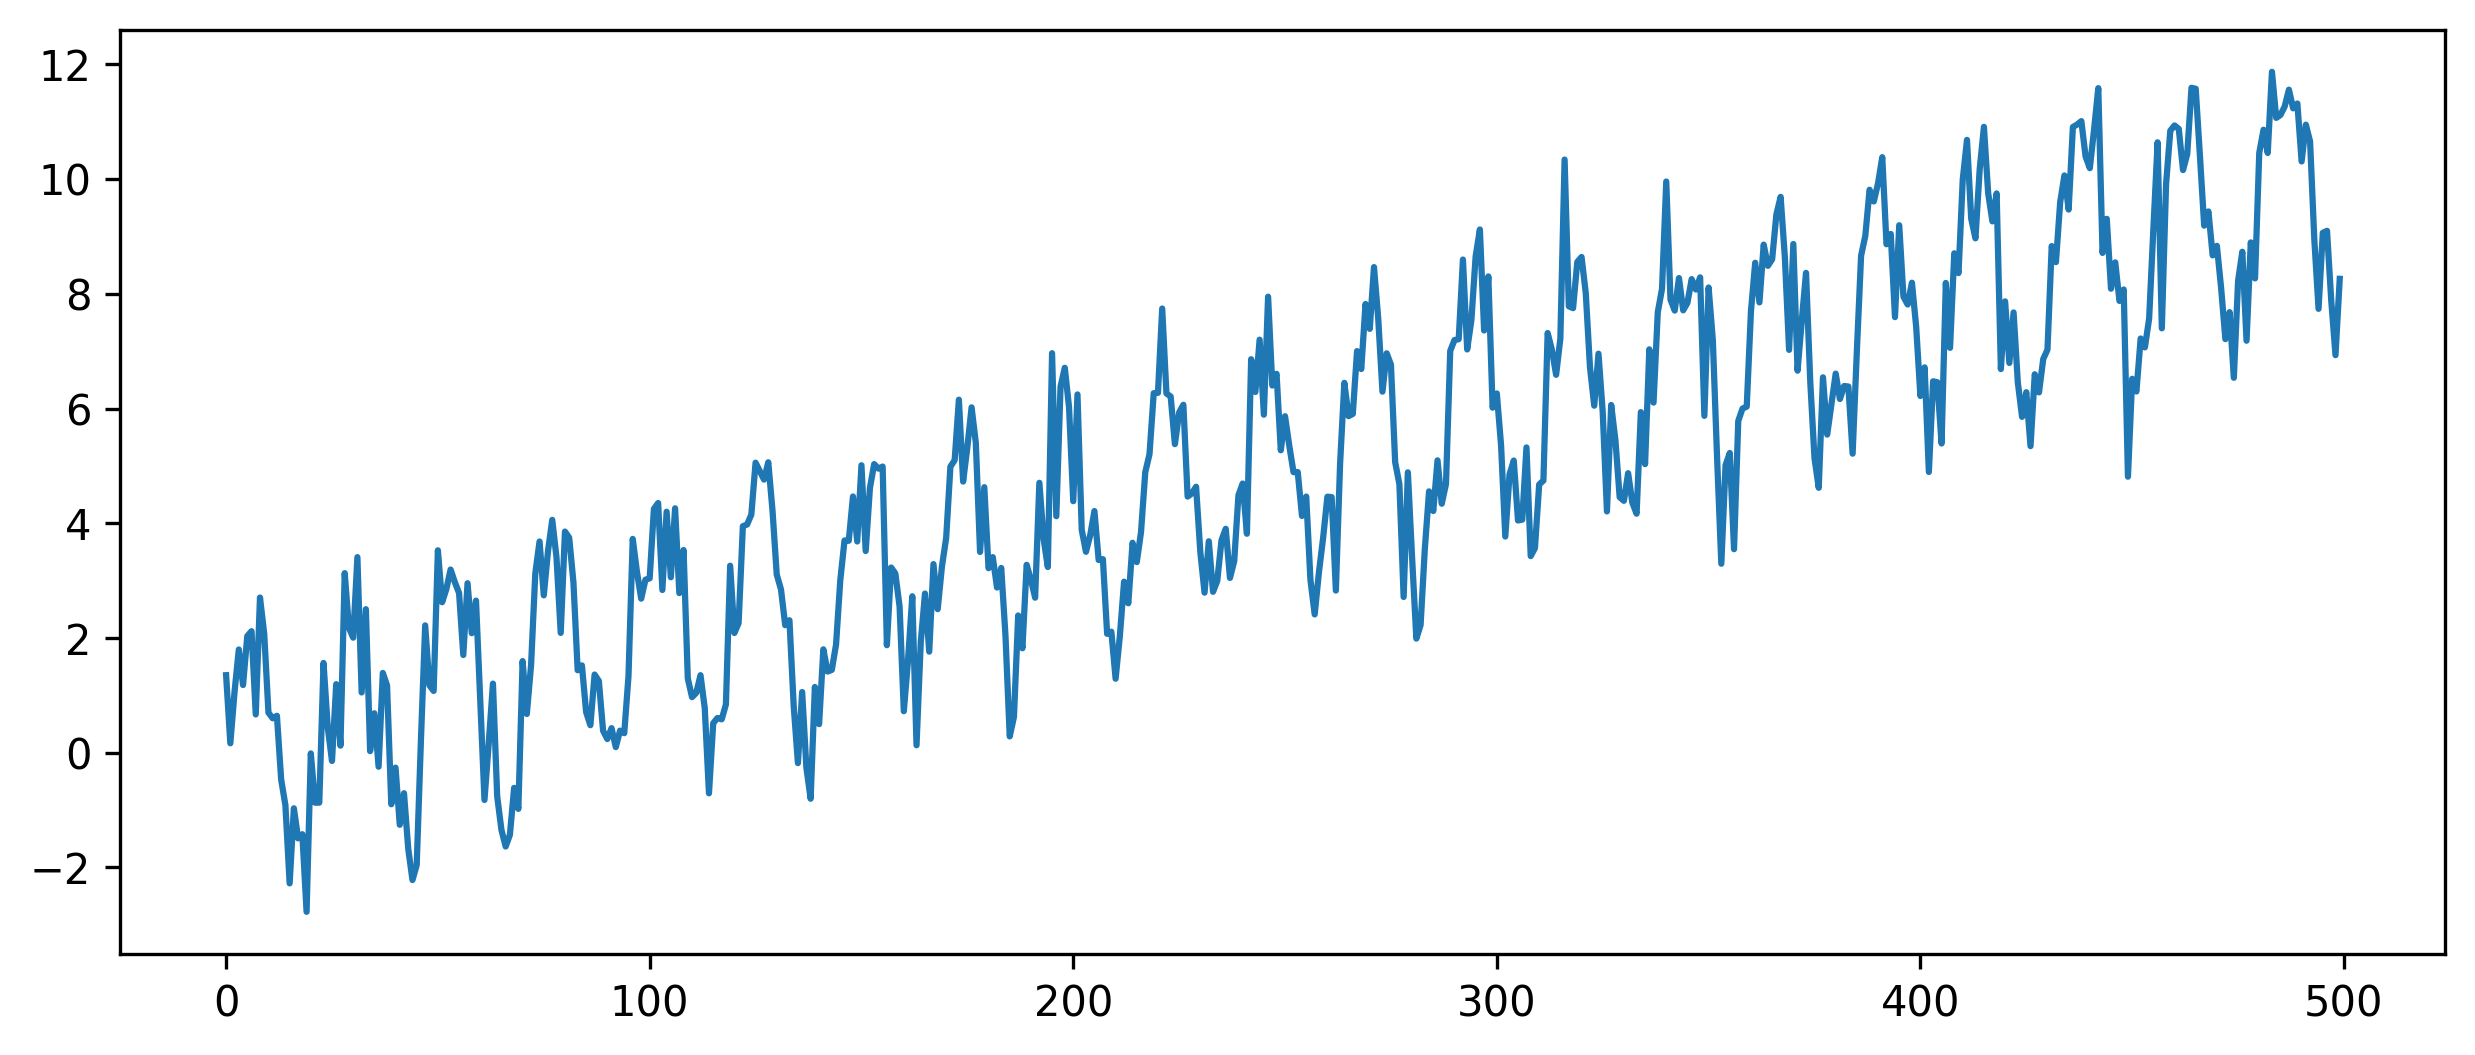

In [6]:
# 1) Create a synthetic seasonal time series
np.random.seed(7)
N = 500
period = 24
x = np.arange(N)
trend_true = 0.02 * x
season_true = 2 * np.sin(2*np.pi*x/period)
noise = np.random.normal(scale=0.8, size=N)
y = trend_true + season_true + noise

plt.figure(dpi=300, figsize=(10, 4))
plt.plot(x, y, label='Synthetic Data')

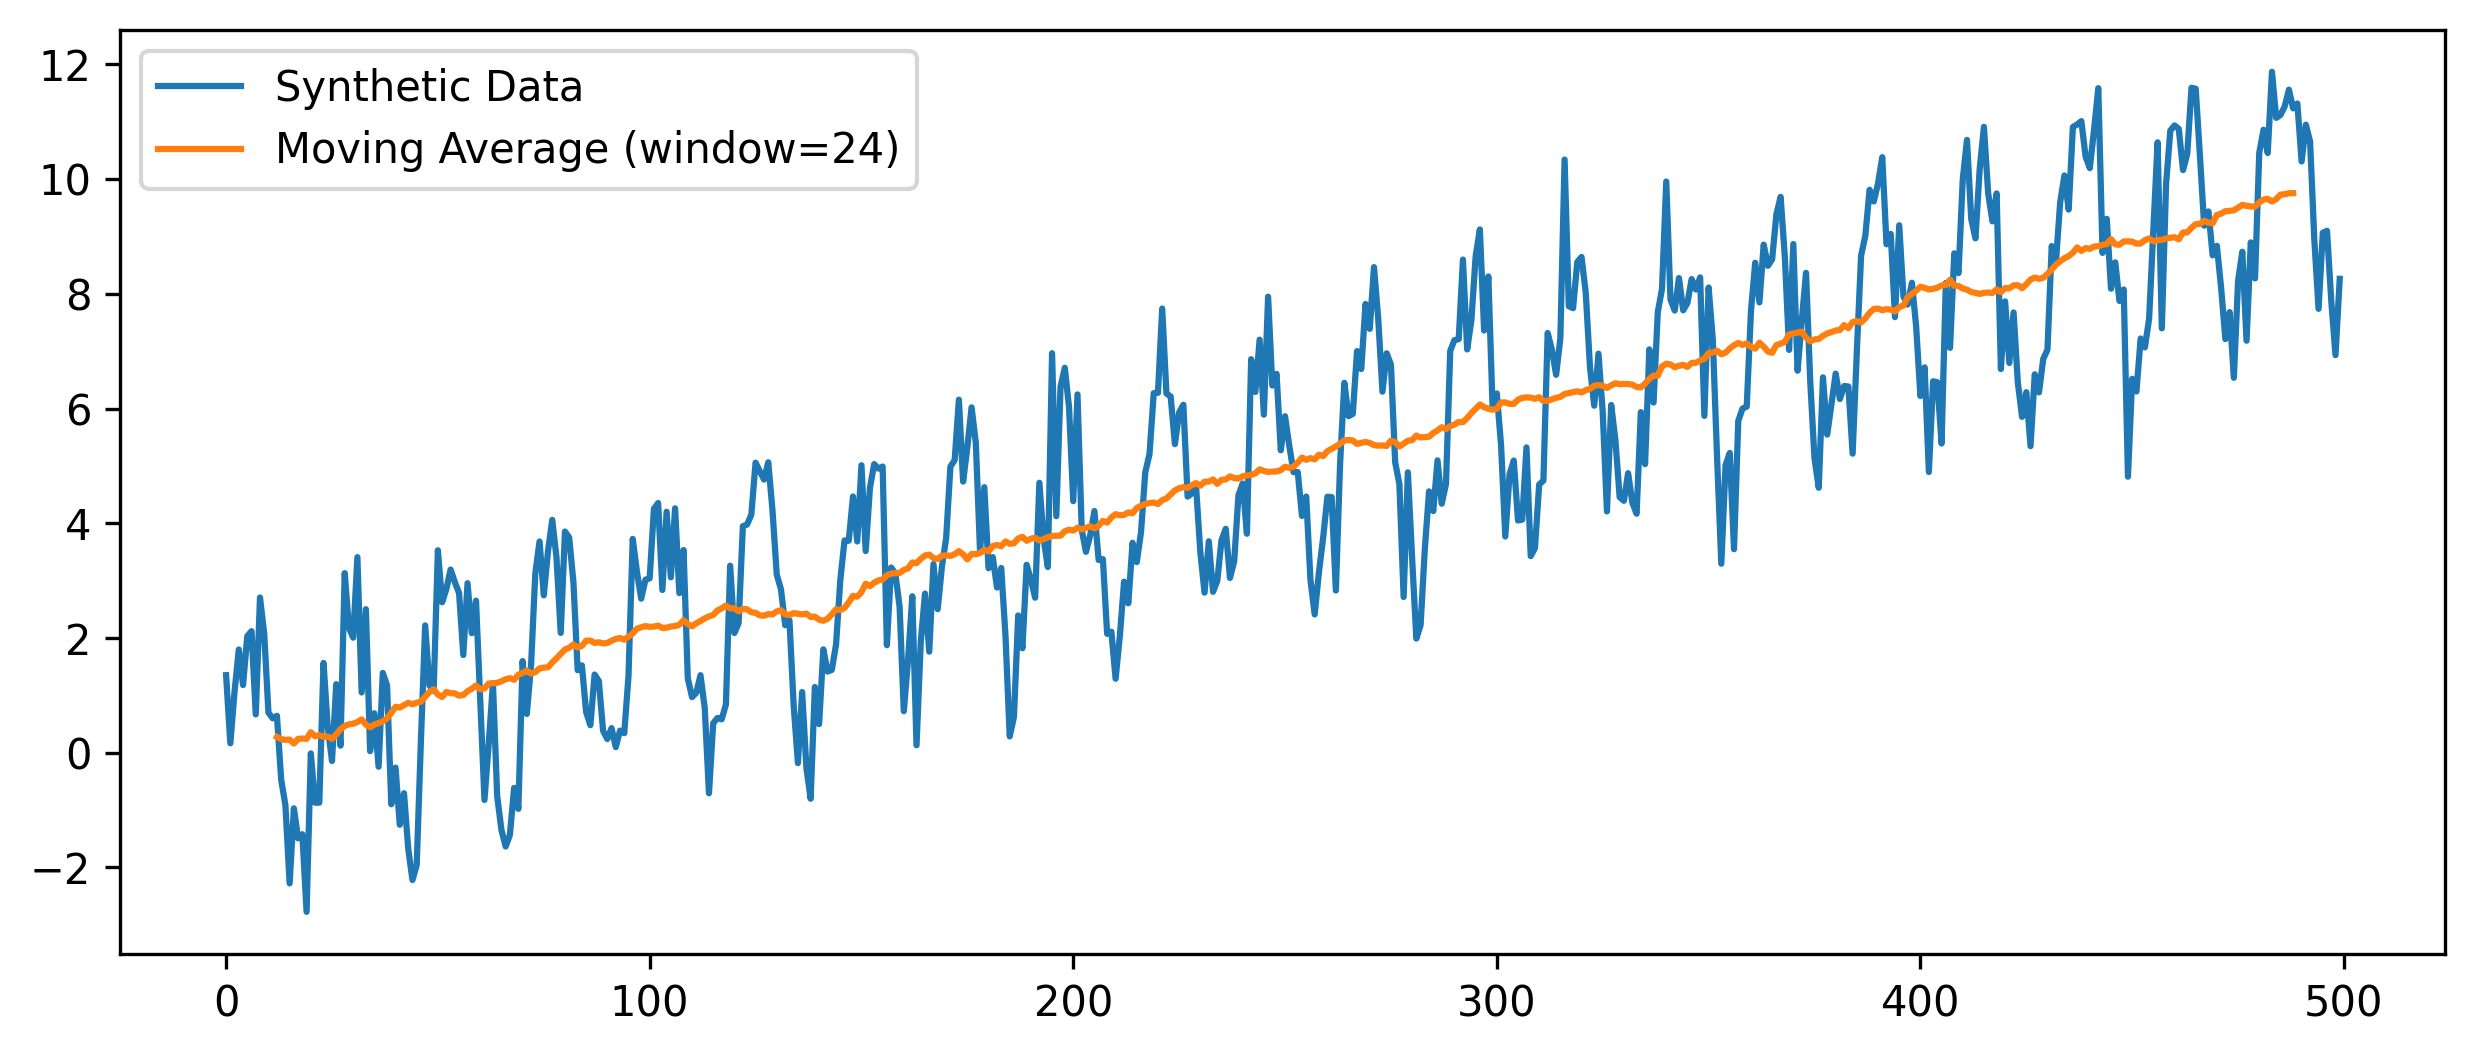

In [7]:
# 2) Moving average (simple smoothing)
window = 24
ma = pd.Series(y).rolling(window=window, center=True).mean()

plt.figure(dpi=300, figsize=(10, 4))
plt.plot(x, y, label='Synthetic Data')
ma.plot(label='Moving Average (window=24)')
plt.legend()


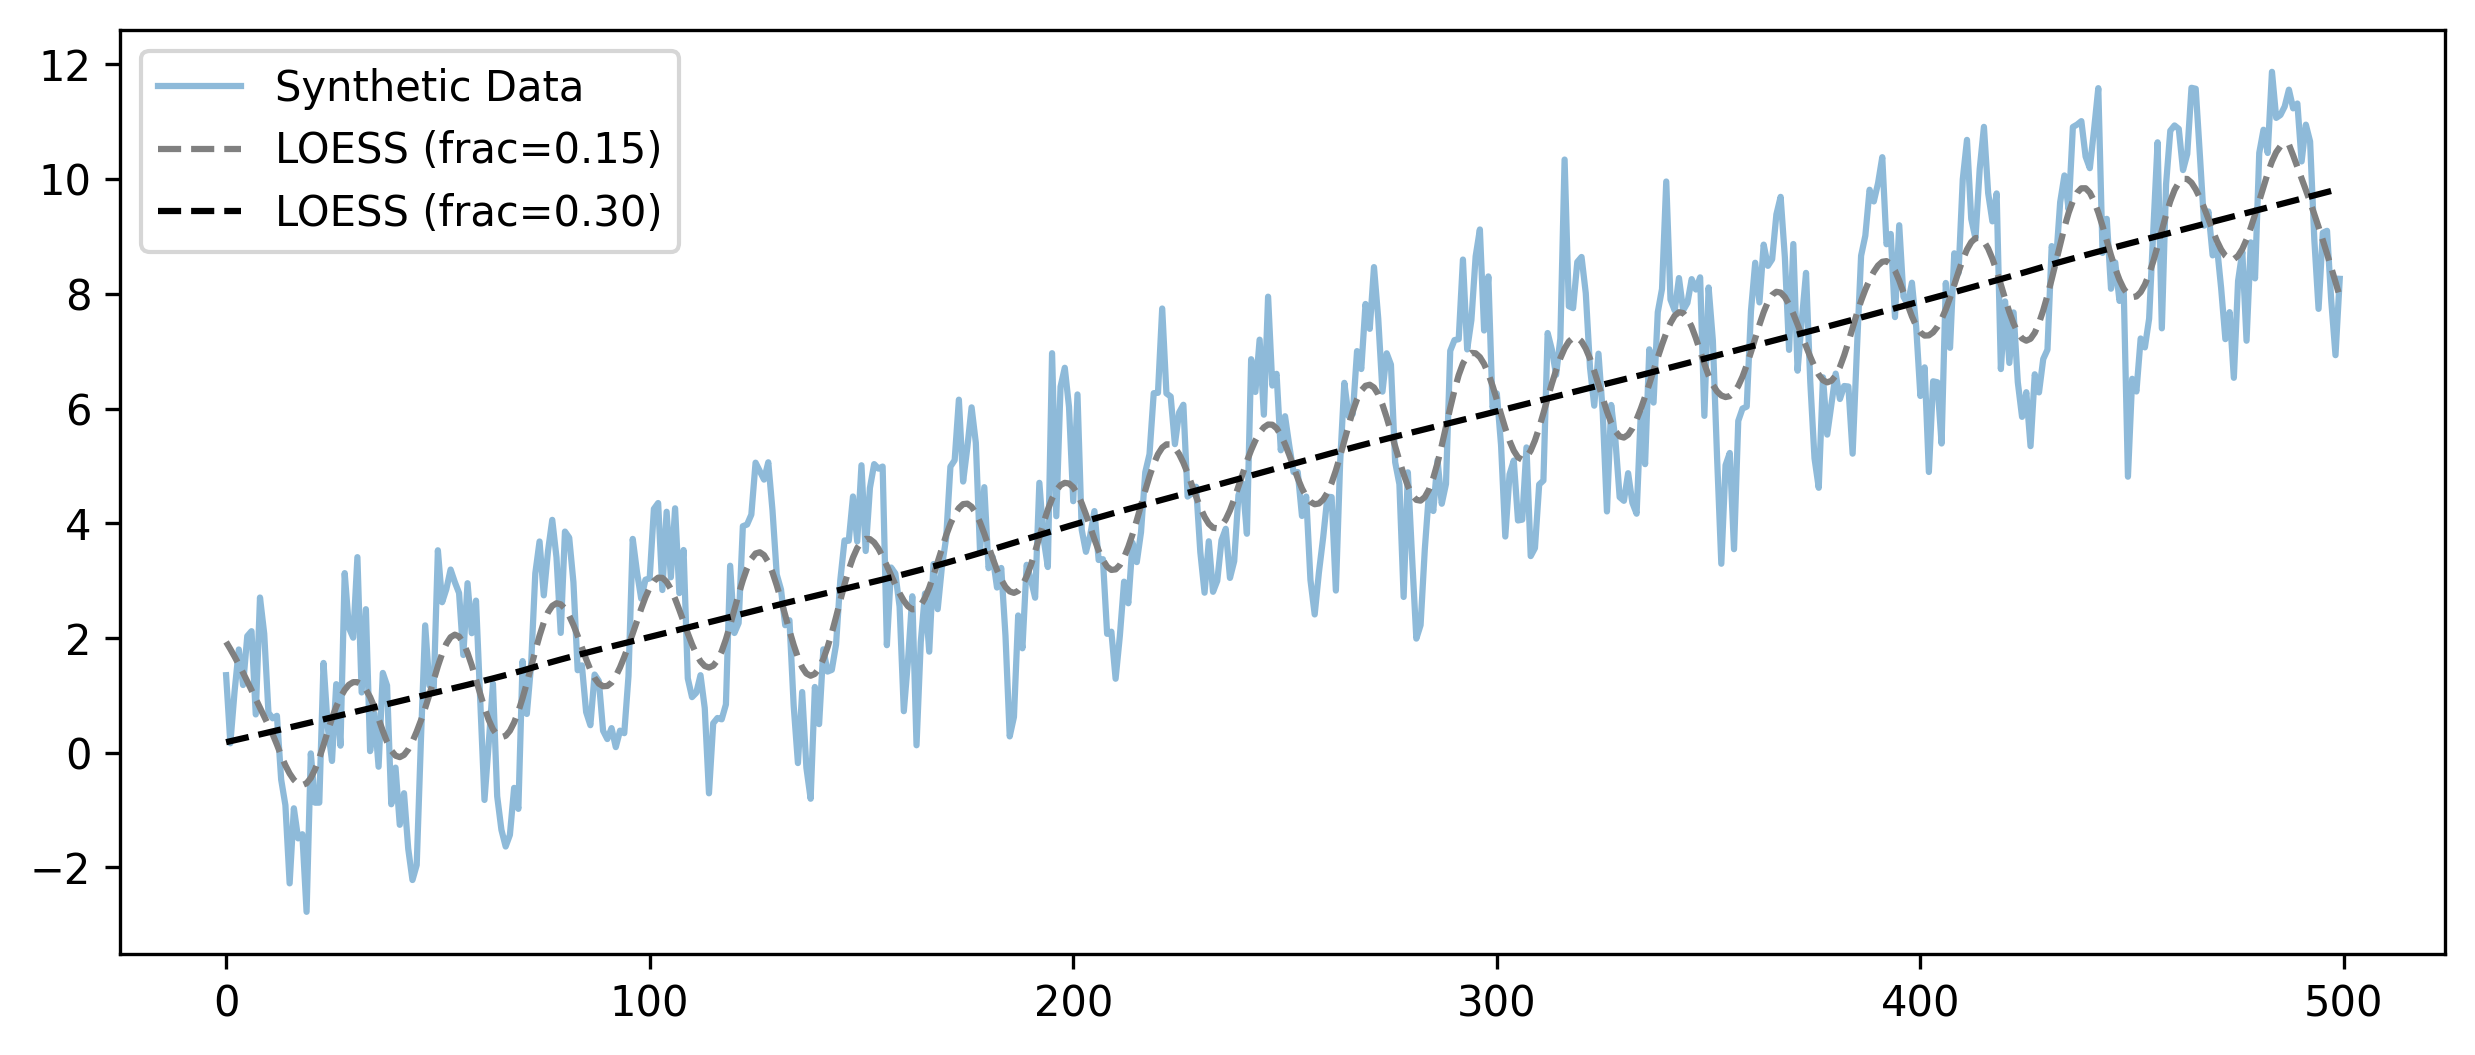

In [8]:
# 3) LOESS smoothing (local linear) for comparison
loess_curve_015 = lowess(y, x, frac=0.05, it=0, return_sorted=False)
loess_curve_030 = lowess(y, x, frac=0.3, it=0, return_sorted=False)


plt.figure(dpi=300, figsize=(10, 4))
plt.plot(x, y, label='Synthetic Data',alpha=0.5)
plt.plot(x, loess_curve_015, label='LOESS (frac=0.15)', color='gray',ls='--')
plt.plot(x, loess_curve_030, label='LOESS (frac=0.30)', color='k',ls='--')
# ma.plot(label='Moving Average (window=24)')
plt.legend()



In [9]:
# 4) STL decomposition
series = pd.Series(y, index=pd.RangeIndex(start=0, stop=N))
stl = STL(series, period=period, robust=True)
res = stl.fit()

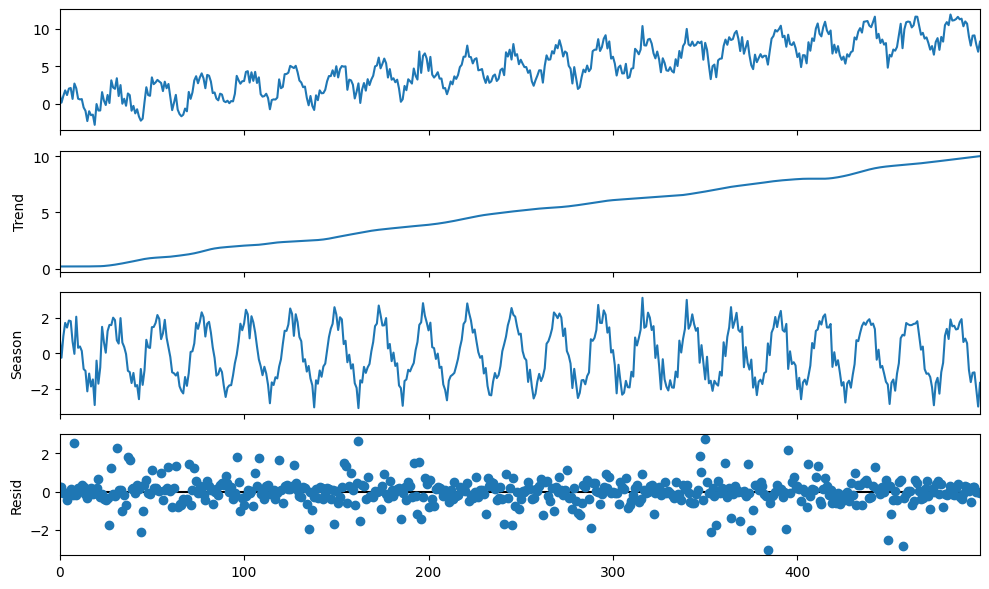

In [10]:
# 5) Plot STL components
fig = res.plot(); fig.set_size_inches(10,6)
plt.tight_layout(); #plt.savefig('stl_components.png', dpi=160)



Files written: smooth_ma_loess.png, stl_components.png, stl_resid_diagnostics.png


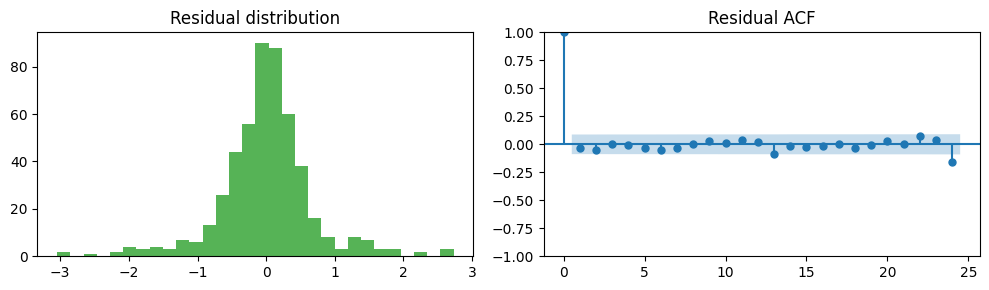

In [11]:
# 7) Residual diagnostics (autocorrelation proxy & histogram)
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(1,2, figsize=(10,3))
ax[0].hist(res.resid, bins=30, color='tab:green', alpha=0.8)
ax[0].set_title('Residual distribution')
plot_acf(res.resid, lags=24, ax=ax[1])
ax[1].set_title('Residual ACF')
plt.tight_layout(); plt.savefig('stl_resid_diagnostics.png', dpi=300)

print('Files written: smooth_ma_loess.png, stl_components.png, stl_resid_diagnostics.png')

# auto-regression - teaser

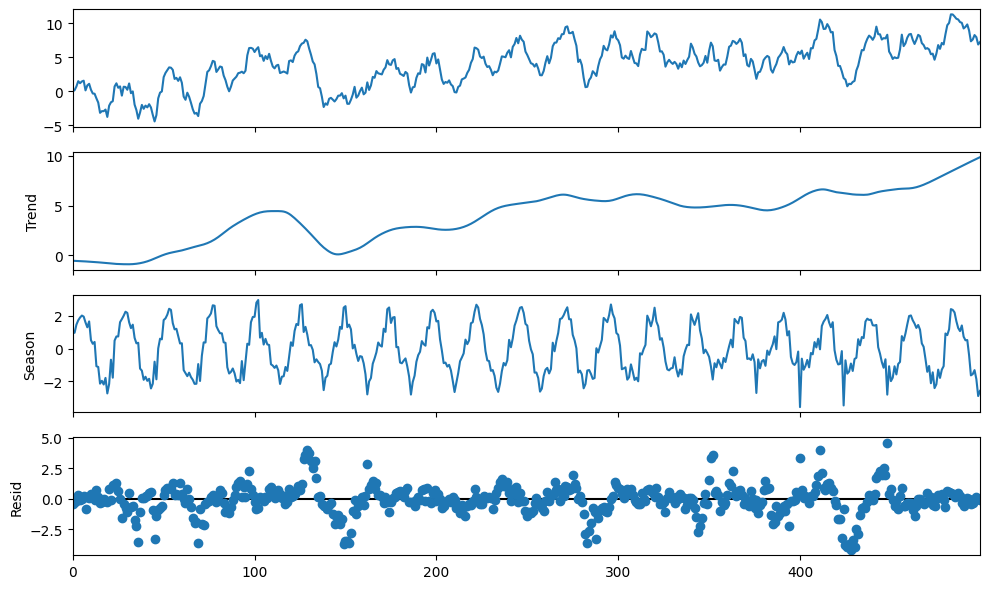

In [12]:
np.random.seed(7)
N = 500
period = 24
x_ac = np.arange(N)
trend_true_ac = 0.02 * x_ac
season_true_ac = 2 * np.sin(2*np.pi*x_ac/period)

# --- AR(1) noise: epsilon_t = phi*epsilon_{t-1} + u_t
phi = 0.95              # autocorrelation strength
sigma_u = 0.8          # innovation std
u = np.random.normal(scale=sigma_u, size=N)
eps = np.zeros(N)
for t in range(1, N):
    eps[t] = phi*eps[t-1] + u[t]

# --- Construct series with AR noise
y_ac = trend_true_ac + season_true_ac + eps

# --- STL
series_ac = pd.Series(y_ac, index=pd.RangeIndex(N))
res_ac = STL(series_ac, period=period, robust=True).fit()

# --- Plot decomposition and residual ACF
fig = res_ac.plot()
fig.set_size_inches(10,6)
plt.tight_layout(); plt.show()


<Figure size 700x300 with 0 Axes>

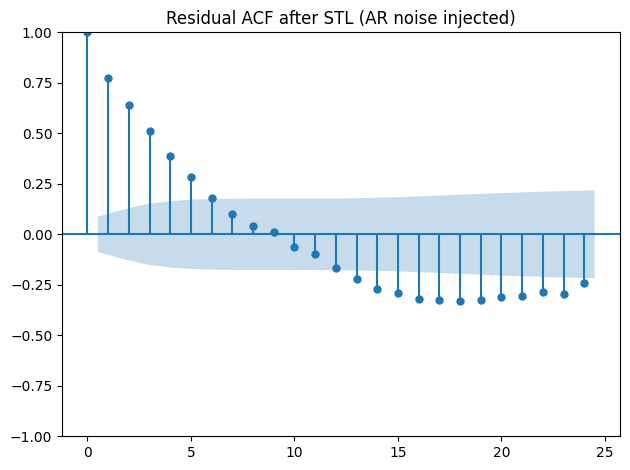

In [13]:
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(7,3))
plot_acf(res_ac.resid, lags=24)
plt.title("Residual ACF after STL (AR noise injected)")
plt.tight_layout(); plt.show()